You could use this notebook on [Google Colab](https://colab.research.google.com/) with a GPU Hardware Accelerator runtype.

# Setup


In [8]:
#For some reason pip3 install -r requirements.txt doesn't work on Colab
! pip3 install -r requirements.txt

     ------------------------------------ 285.2/285.2 kB 332.1 kB/s eta 0:00:00



[notice] A new release of pip available: 22.2.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Exploratory Data Analysis
A key to the usefulness of this program is understanding the dataset. Knowing the limitations of the current data adds context to the predictions made by the program.

In [22]:
# Import necessary libraries
import pandas as pd
import numpy as np
from nba_api.stats.endpoints import teamgamelog, cumestatsteamgames, cumestatsteam, gamerotation, boxscoreadvancedv3, leaguegamefinder
from nba_api.stats.static import teams, players
import matplotlib.pyplot as plt
import seaborn as sns
import json

pd.options.display.max_columns = None
pd.options.display.max_rows = None

In [30]:
nba_teams = teams.get_teams()
print(f"Number of teams fetched: {len(nba_teams)}")
celtics = [team for team in nba_teams if team['abbreviation'] == 'BOS'][0]
celtics_id = celtics['id']

# query for games where the celtics were playing
gamefinder = leaguegamefinder.LeagueGameFinder(team_id_nullable=celtics_id)
games = gamefinder.get_data_frames()[0]
# Will only give stats for the Celtics, not the opponent
games.columns


Number of teams fetched: 30


Index(['SEASON_ID', 'TEAM_ID', 'TEAM_ABBREVIATION', 'TEAM_NAME', 'GAME_ID',
       'GAME_DATE', 'MATCHUP', 'WL', 'MIN', 'PTS', 'FGM', 'FGA', 'FG_PCT',
       'FG3M', 'FG3A', 'FG3_PCT', 'FTM', 'FTA', 'FT_PCT', 'OREB', 'DREB',
       'REB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PLUS_MINUS'],
      dtype='object')

In [28]:
games.groupby(games.SEASON_ID.str[-4:])[['GAME_ID']].count()

,GAME_ID
SEASON_ID,
1983,105
1984,103
1985,100
1986,105
1987,99
1988,85
1989,87
1990,93
1991,92


In [73]:
# get all the games
result = leaguegamefinder.LeagueGameFinder(league_id_nullable='00', season_type_nullable='Regular Season')
all_games = result.get_data_frames()[0]
# Example game
full_game = all_games[all_games.GAME_ID == '0022401058']
full_game

,SEASON_ID,TEAM_ID,TEAM_ABBREVIATION,TEAM_NAME,GAME_ID,GAME_DATE,MATCHUP,WL,MIN,PTS,FGM,FGA,FG_PCT,FG3M,FG3A,FG3_PCT,FTM,FTA,FT_PCT,OREB,DREB,REB,AST,STL,BLK,TOV,PF,PLUS_MINUS
20,22024,1610612756,PHX,Phoenix Suns,0022401058,2025-03-26,PHX vs. BOS,L,239,102,36,87,0.414,13,41,0.317,17,21,0.810,11,27,38,22,7,3,13,18,-30.0
25,22024,1610612738,BOS,Boston Celtics,0022401058,2025-03-26,BOS @ PHX,W,239,132,45,89,0.506,22,52,0.423,20,22,0.909,11,37,48,33,8,7,10,18,30.0


In [74]:
all_games['GAME_DATE'] = pd.to_datetime(all_games['GAME_DATE'], format='%Y-%m-%d')
all_games = all_games.sort_values(['TEAM_ID', 'GAME_DATE'], ascending=True)
print(all_games.head(5))


# prepare data
features = ['PTS', 'FGM', 'FG_PCT', 'FG3M', 'FG3_PCT', 'FTM', 'FT_PCT', 'OREB', 'DREB', 'AST', 'STL', 'BLK', 'TOV', 'PF']

      SEASON_ID     TEAM_ID TEAM_ABBREVIATION      TEAM_NAME     GAME_ID  \
29974     22012  1610612737               ATL  Atlanta Hawks  0021200542   
29943     22012  1610612737               ATL  Atlanta Hawks  0021200558   
29922     22012  1610612737               ATL  Atlanta Hawks  0021200572   
29893     22012  1610612737               ATL  Atlanta Hawks  0021200588   
29880     22012  1610612737               ATL  Atlanta Hawks  0021200594   

       GAME_DATE      MATCHUP WL  MIN  PTS  FGM  FGA  FG_PCT  FG3M  FG3A  \
29974 2013-01-12    ATL @ WAS  L  239   83   30   78   0.385     7    24   
29943 2013-01-14    ATL @ CHI  L  240   58   24   82   0.293     2    14   
29922 2013-01-16  ATL vs. BKN  W  239  109   45   78   0.577     8    21   
29893 2013-01-18    ATL @ BKN  L  241   89   35   80   0.438     9    21   
29880 2013-01-19  ATL vs. SAS  L  240   93   35   85   0.412     8    21   

       FG3_PCT  FTM  FTA  FT_PCT  OREB  DREB  REB  AST  STL  BLK  TOV  PF  \
29974    

In [75]:
celtics_games = all_games[all_games['TEAM_ID'] == 1610612738]
celtics_games['ROLLING_PTS'] = celtics_games.shift(1).rolling(window=5, min_periods=0)['PTS'].mean()
print(celtics_games.head(10))

      SEASON_ID     TEAM_ID TEAM_ABBREVIATION       TEAM_NAME     GAME_ID  \
29994     22012  1610612738               BOS  Boston Celtics  0021200531   
29956     22012  1610612738               BOS  Boston Celtics  0021200557   
29915     22012  1610612738               BOS  Boston Celtics  0021200573   
29890     22012  1610612738               BOS  Boston Celtics  0021200584   
29861     22012  1610612738               BOS  Boston Celtics  0021200603   
29836     22012  1610612738               BOS  Boston Celtics  0021200614   
29808     22012  1610612738               BOS  Boston Celtics  0021200630   
29800     22012  1610612738               BOS  Boston Celtics  0021200633   
29762     22012  1610612738               BOS  Boston Celtics  0021200652   
29710     22012  1610612738               BOS  Boston Celtics  0021200672   

       GAME_DATE      MATCHUP WL  MIN  PTS  FGM  FGA  FG_PCT  FG3M  FG3A  \
29994 2013-01-11  BOS vs. HOU  W  240  103   41   79   0.519     9    23   


C:\Users\order\AppData\Local\Temp\ipykernel_17864\2887572686.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  celtics_games['ROLLING_PTS'] = celtics_games.shift(1).rolling(window=5, min_periods=0)['PTS'].mean()


## Feature Definitions

Each row represents a matchup between two teams.  
TEAM_NAME: Name of the home team. All team statistics count that season's games up to but not including the current game
Days-Rest-Home: The difference in days between the current game and the home team's previous game
GP: games played by the home team
W: wins by the home team
L: losses by the home team
W_PCT: win percentage of the home team
MIN: total minutes  
FGM: Made field goals  
FGA: attempted field goals  
FG_PCT: percentage of field goals made  
FG3M: three point field goals made  
FG3A: three point field goals attempted  
FG3_PCT: percentage of three point field goals made  
FTM: free throws made  
FTA: free throws attempted   
FT_PCT: percentage of free throws made  
OREB: offensive rebounds  
DREB: defensive rebounds  
REB: total rebounds  
AST: assists  
TOV: turnovers  
STL: steals  
BLK: blocks  
BLKA: blocks against  
PF: personal fouls   
PFD: personal fouls drawn  
PTS: total points  
PLUS_MINUS: point differential   
TEAM_NAME.1: Name of the away team. The away team's statistics are represented with a '.1' suffix  
Days-Rest-Away: Days of rest since the away team's previous game
Date(str): Date of the game in format '2012-11-04'  
Home-Team-Win(float): A boolean representing whether the home team won the game  
Score(float): The total score for the game  
OU(float): The predicted over-under value by the sportsbook before the game  
OU-Cover(float): Whether the game's total score exceeded the over under  

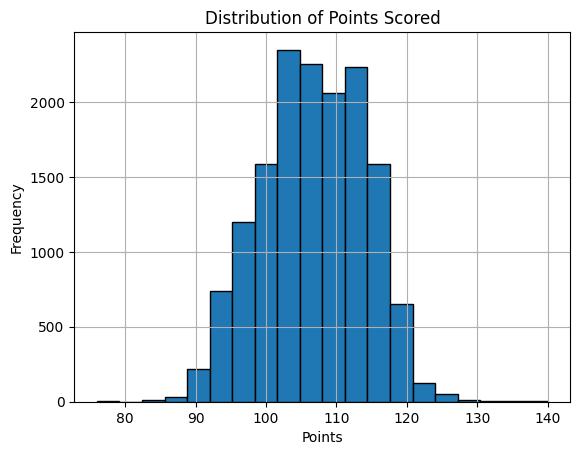

In [7]:
# visualize the points distribution
average_points = main_dataset['PTS']

plt.hist(main_dataset['PTS'], bins=20, edgecolor='black')
plt.title('Distribution of Points Scored')
plt.xlabel('Points')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

# TODO:
Where is the over under coming from for these games before gambling was legal?  
Clean data: convert to ints, remove highly correlated features, remove ranks  
minutes: include to normalize overtime games  
points: normalize based on average for a season
data warehousing: store the data in a way so that it is easier to run high level queries eg. get all of the Lakers games for the 2024-2025 season: model for team, game, and season
The goal is to create sequences of the previous 5 games for each team including statistics for and statistics allowed
